<a href="https://colab.research.google.com/github/mreguant/pypsa-tutorial/blob/main/notebooks/up-and-running.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Up and running
This notebook will load an .nc file, explore it and modify it.

## Preliminaries

In [2]:
%%capture
# @title
# 1. Install PyPSA
!pip install pypsa

# 2. Install an open-source solver (GLPK is easiest for Colab)
!apt-get install -y glpk-utils

# 3. (Optional) Install linopy (the library PyPSA uses for optimization)
!pip install linopy

In [3]:
import pypsa
import pandas as pd

## Loading network and exploring
We load a network that we already generated, which is a small example network from Belgium.

In [34]:
# 1. Load the Network
n = pypsa.Network(r'https://mreguant.github.io/pypsa-tutorial/assets/networks/base_s_6_elec.nc')
n.sanitize()
n.explore()

<IPython.core.display.Javascript object>

{
  "initialViewState": {
    "bearing": 0,
    "latitude": 50.683361854115525,
    "longitude": 4.985184143664467,
    "pitch": 0,
    "zoom": 4
  },
  "layers": [
    {
      "@@type": "PathLayer",
      "autoHighlight": true,
      "data": [
        {
          "bus0": "BE0 0",
          "bus1": "BE0 2",
          "color": "rosybrown",
          "name": "0",
          "path": [
            [
              4.3647257932428305,
              50.58374729848674
            ],
            [
              4.296913497547355,
              51.13302892385811
            ]
          ],
          "rgba": [
            188,
            143,
            143,
            230
          ],
          "tooltip_html": "<b>0</b>\n<table>\n<tr><td style='font-weight:bold'>bus0:</td><td style='text-align:left'>BE0 0</td></tr>\n<tr><td style='font-weight:bold'>bus1:</td><td style='text-align:left'>BE0 2</td></tr>\n<tr><td style='font-weight:bold'>color:</td><td style='text-align:left'>rosybrown</td></tr>\n<tr><td style='font-weight:bold'>width:</td><td style='text-align:left'>2</td></tr>\n</table>",
          "width": 2,
          "width_pdk": 2000.0
        },
        {
          "bus0": "BE0 0",
          "bus1": "BE0 5",
          "color": "rosybrown",
          "name": "1",
          "path": [
            [
              4.3647257932428305,
              50.58374729848674
            ],
            [
              5.10139007756198,
              50.510816357470944
            ]
          ],
          "rgba": [
            188,
            143,
            143,
            230
          ],
          "tooltip_html": "<b>1</b>\n<table>\n<tr><td style='font-weight:bold'>bus0:</td><td style='text-align:left'>BE0 0</td></tr>\n<tr><td style='font-weight:bold'>bus1:</td><td style='text-align:left'>BE0 5</td></tr>\n<tr><td style='font-weight:bold'>color:</td><td style='text-align:left'>rosybrown</td></tr>\n<tr><td style='font-weight:bold'>width:</td><td style='text-align:left'>2</td></tr>\n</table>",
          "width": 2,
          "width_pdk": 2000.0
        },
        {
          "bus0": "BE0 1",
          "bus1": "BE0 3",
          "color": "rosybrown",
          "name": "2",
          "path": [
            [
              5.578526802085405,
              50.726249549740444
            ],
            [
              5.723804065173548,
              49.99475407820011
            ]
          ],
          "rgba": [
            188,
            143,
            143,
            230
          ],
          "tooltip_html": "<b>2</b>\n<table>\n<tr><td style='font-weight:bold'>bus0:</td><td style='text-align:left'>BE0 1</td></tr>\n<tr><td style='font-weight:bold'>bus1:</td><td style='text-align:left'>BE0 3</td></tr>\n<tr><td style='font-weight:bold'>color:</td><td style='text-align:left'>rosybrown</td></tr>\n<tr><td style='font-weight:bold'>width:</td><td style='text-align:left'>2</td></tr>\n</table>",
          "width": 2,
          "width_pdk": 2000.0
        },
        {
          "bus0": "BE0 1",
          "bus1": "BE0 4",
          "color": "rosybrown",
          "name": "3",
          "path": [
            [
              5.578526802085405,
              50.726249549740444
            ],
            [
              4.845744626375684,
              51.151574916936795
            ]
          ],
          "rgba": [
            188,
            143,
            143,
            230
          ],
          "tooltip_html": "<b>3</b>\n<table>\n<tr><td style='font-weight:bold'>bus0:</td><td style='text-align:left'>BE0 1</td></tr>\n<tr><td style='font-weight:bold'>bus1:</td><td style='text-align:left'>BE0 4</td></tr>\n<tr><td style='font-weight:bold'>color:</td><td style='text-align:left'>rosybrown</td></tr>\n<tr><td style='font-weight:bold'>width:</td><td style='text-align:left'>2</td></tr>\n</table>",
          "width": 2,
          "width_pdk": 2000.0
        },
        {
          "bus0": "BE0 1",
          "bus1": "BE0 4",
          "color": "rosybrown",
  

A network is a collection of assets, functions, and results (if it has been solved for).

In [16]:
n

PyPSA Network ''
----------------
Components:
 - Bus: 12
 - Carrier: 17
 - Generator: 32
 - GlobalConstraint: 1
 - Line: 8
 - Link: 12
 - Load: 6
 - StorageUnit: 6
 - Store: 6
Snapshots: 7

We can access the attributes of different resources by looking at their characteristics. You can see the list of resources and what they do [here](https://docs.pypsa.org/stable/user-guide/components/buses/).

In [28]:
n.lines

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,dc,v_nom,i_nom
name,,,,,,,,,,,,,,,,,,,,,
0,BE0 0,BE0 2,Al/St 240/40 4-bundle 380.0,7.535288,0.918938,0.0,0.000531,3396.205223,0.0,True,...,0.0,0.0,0.0,0.0,0.000052,0.000006,3396.205223,0.0,380.0,2.58
1,BE0 0,BE0 5,Al/St 240/40 4-bundle 380.0,6.479495,0.790182,0.0,0.000457,3396.205223,0.0,True,...,0.0,0.0,0.0,0.0,0.000045,0.000005,3396.205223,0.0,380.0,2.58
2,BE0 1,BE0 3,Al/St 240/40 4-bundle 380.0,69.675570,8.497021,0.0,0.000103,491.556019,0.0,True,...,0.0,0.0,0.0,0.0,0.000483,0.000059,491.556019,0.0,380.0,2.58
3,BE0 1,BE0 4,Al/St 240/40 4-bundle 380.0,17.172495,2.094207,0.0,0.000303,1698.102612,0.0,True,...,0.0,0.0,0.0,0.0,0.000119,0.000015,1698.102612,0.0,380.0,2.58
4,BE0 1,BE0 4,Al/St 240/40 4-bundle 380.0,8.586235,1.047102,0.0,0.000605,3396.210000,0.0,True,...,0.0,0.0,0.0,0.0,0.000059,0.000007,3396.210000,NaN,380.0,2.58
5,BE0 1,BE0 5,Al/St 240/40 4-bundle 380.0,3.387897,0.413158,0.0,0.000537,5094.307835,0.0,True,...,0.0,0.0,0.0,0.0,0.000023,0.000003,5094.307835,0.0,380.0,2.58
6,BE0 2,BE0 4,Al/St 240/40 4-bundle 380.0,4.716211,0.575148,0.0,0.000332,3396.205223,0.0,True,...,0.0,0.0,0.0,0.0,0.000033,0.000004,3396.205223,0.0,380.0,2.58
7,BE0 3,BE0 5,Al/St 240/40 4-bundle 380.0,8.913106,1.086964,0.0,0.000628,3396.205223,0.0,True,...,0.0,0.0,0.0,0.0,0.000062,0.000008,3396.205223,0.0,380.0,2.58


We can also see their evolution over time. In this case, the flows (active power) that go over the lines ('p0').

In [30]:
n.lines_t.p0

name,0,1,2,3,4,5,6,7
snapshot,,,,,,,,
2013-03-01,-217.694241,-448.681651,61.103386,57.430440,114.861042,-730.952631,465.580217,-755.494905
2013-03-02,83.473039,-548.111641,46.616910,125.286275,250.572902,-792.511298,139.082956,-665.649782
2013-03-03,348.605612,-624.038312,29.972068,186.032683,372.065889,-904.711630,-87.057531,-578.181324
2013-03-04,108.138825,-962.254064,11.571129,192.282577,384.565695,-911.362804,-139.985825,-436.865550
2013-03-05,98.380117,-784.897937,34.310106,160.274961,320.550373,-851.815788,-40.049020,-591.986788
2013-03-06,158.649370,-596.256802,42.133755,144.330885,288.662177,-835.430029,53.000312,-646.917579
2013-03-07,-121.641654,-472.663624,60.193524,76.158677,152.317568,-739.534658,353.522163,-751.644377


We can also plot the results.

(<Figure size 819.875x300 with 1 Axes>,
 <Axes: xlabel='snapshot', ylabel='Energy Balance'>,
 <seaborn.axisgrid.FacetGrid at 0x7fda4f9b9df0>)

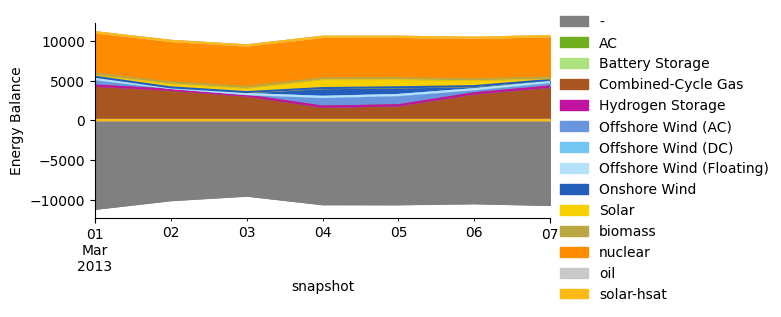

In [35]:
n.statistics.energy_balance.plot()

## Modifying the network and comparing